![Banner PTI Clima](https://raw.githubusercontent.com/SantanderMetGroup/PTI-Clima-Datalab/devel/aux/Banner-logos-PTIClima-ProyectoServiciosAEMET.png)

# Datalab de la Plataforma Estatal de Servicios Climáticos 

***
> Los cuadernos (Jupyter Notebooks) incluidos en este Datalab muestran ejemplos prácticos para utilizar, transformar y visualizar los conjuntos de datos disponibles en el [almacén de datos](https://pti.climate.ifca.es/data) de la Plataforma Estatal de Servicios Climáticos.
>
> Este trabajo está licenciado bajo una [Licencia Creative Commons Atribución 4.0 Internacional](http://creativecommons.org/licenses/by/4.0).
>
> ![Licencia de Creative Commons](https://i.creativecommons.org/l/by/4.0/88x31.png)


## Guía para el cálculo del índice: CDD (Consecutive Dry Days)

**M.ª I. de la Osa Rocha** (Instituto de Física de Cantabria, CSIC-Universidad de Cantabria, Santander, Spain).

En este notebook verás cómo calcular el índice de **días secos consecutivos** (**CDD, Consecutive Dry Days**), también denominado **Maximum length of dry spell**, utilizando los conjuntos de datos disponibles en el Almacén de Datos de la Plataforma Estatal de Servicios Climáticos. Este índice representa la longitud máxima de una racha seca, definida como el mayor número de días consecutivos con precipitación diaria inferior a 1 mm.

El ejemplo utiliza la precipitación diaria (`pr`) como variable de entrada y carga años completos, para evitar problemas en el cálculo de índices climáticos que requieren series anuales completas. Además, para facilitar su ejecución en Binder, el notebook usa un periodo temporal reducido y un dominio espacial pequeño.

La Plataforma Virtual de Cálculo ofrece, además, un **notebook de primeros pasos** y una **colección de notebooks temáticos** que pueden consultarse para ampliar el uso de las herramientas y profundizar en los análisis a partir de los datos disponibles en el Almacén.


Antes de empezar, o en cualquier momento durante el cuaderno, podemos personalizar el área de visualización de gráficos de la siguiente manera:

In [1]:
library(repr)
# Change plot size 
options(repr.plot.width=12, repr.plot.height=5)

### Contenido de este cuaderno:
*  [1. Carga de librerías](#1-bullet)
*  [2. Carga de datos](#2-bullet)
*  [3. Cálculo del índice y visualización](#3-bullet)

## 1 Carga de librerías <a class="anchor" id="1-bullet"></a>

Para las operaciones que se llevan a cabo en este notebook necesitaremos cuatro librerías de ***climate4R***: `loadeR` para la carga de datos, `transformeR` para calcular agregaciones temporales y extraer subconjuntos de información, `visualizeR` para la representación gráfica de los resultados y `climate4R.climdex` para el cálculo del índice ETCCDI.


In [2]:
library(loadeR)
library(transformeR)
library(visualizeR)
library(climate4R.climdex)


Loading required package: rJava

Loading required package: loadeR.java

Java version 22x amd64 by N/A detected

NetCDF Java Library v4.6.0-SNAPSHOT (23 Apr 2015) loaded and ready

Loading required package: climate4R.UDG

climate4R.UDG version 0.2.6 (2023-06-26) is loaded

Please use 'citation("climate4R.UDG")' to cite this package.

loadeR version 1.8.1 (2023-06-22) is loaded


Get the latest stable version (1.8.2) using <devtools::install_github(c('SantanderMetGroup/climate4R.UDG','SantanderMetGroup/loadeR'))>

Please use 'citation("loadeR")' to cite this package.




    _______   ____  ___________________  __  ________ 
   / ___/ /  / /  |/  / __  /_  __/ __/ / / / / __  / 
  / /  / /  / / /|_/ / /_/ / / / / __/ / /_/ / /_/_/  
 / /__/ /__/ / /  / / __  / / / / /__ /___  / / \ \ 
 \___/____/_/_/  /_/_/ /_/ /_/  \___/    /_/\/   \_\ 
 
      github.com/SantanderMetGroup/climate4R



transformeR version 2.2.2 (2023-10-26) is loaded


Get the latest stable version (2.2.5) using <devtools::install_github('SantanderMetGroup/transformeR')>

Please see 'citation("transformeR")' to cite this package.

visualizeR version 1.6.4 (2023-10-26) is loaded

Please see 'citation("visualizeR")' to cite this package.

Loading required package: climdex.pcic

Loading required package: PCICt

climate4R.climdex version 0.2.3 (2023-06-23) is loaded

Use 'climdexShow()' for an overview of the available ETCCDI indices



## 2. Carga de datos <a class="anchor" id="2-bullet"></a>


El inventario `data_inventory.csv` cataloga la lista de archivos del Almacén de datos de la PTI-Clima. Consulta `primeros_pasos_R.ipynb` para una explicación detallada.

Basta con leer este archivo mediante `read.csv` para obtener el `data.frame` que contiene esta información.

In [3]:
df <- read.csv("../../data_inventory.csv")

A continuación mostramos el cabecero del inventario.

In [4]:
head(df)

,dataset,type,access,source,provider,experiment,frequency,endpoint,dictionary
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,AEMET-ROCIO-IBEB-regular_Iberia_day,observations,opendap,AEMET-ROCIO-IBEB-regular,,,day,https://thredds.climate.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/AEMET-ROCIO-IBEB/Iberia/day/AEMET-ROCIO-IBEB_Iberia_day.ncml,../../Harmonization_dictionaries/AEMET-ROCIO-regular.dic
2,AEMET-ROCIO-CAN-regular_Canarias_day,observations,opendap,AEMET-ROCIO-CAN-regular,,,day,https://thredds.climate.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/AEMET-ROCIO-CAN/Canarias/day/AEMET-ROCIO-CAN_Canarias_day.ncml,../../Harmonization_dictionaries/AEMET-ROCIO-regular.dic
3,CHELSA-W5E5v1.0_Canarias_day,observations,opendap,CHELSA-W5E5v1.0,,,day,https://thredds.climate.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/CHELSA-W5E5v1.0/Canarias/day/CHELSA-W5E5v1.0_Canarias_day.ncml,../../Harmonization_dictionaries/CHELSA-W5E5v1.0.dic
4,CHELSA-W5E5v1.0_Iberia_day,observations,opendap,CHELSA-W5E5v1.0,,,day,https://thredds.climate.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/CHELSA-W5E5v1.0/Iberia/day/CHELSA-W5E5v1.0_Iberia_day.ncml,../../Harmonization_dictionaries/CHELSA-W5E5v1.0.dic
5,PTI-grid_Canarias_day,observations,opendap,PTI-grid,,,day,https://thredds.climate.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/PTI-grid/Canarias/day/PTI-grid_Canarias_day.ncml,../../Harmonization_dictionaries/PTI-grid.dic
6,PTI-grid_Iberia_day,observations,opendap,PTI-grid,,,day,https://thredds.climate.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/PTI-grid/Iberia/day/PTI-grid_Iberia_day.ncml,../../Harmonization_dictionaries/PTI-grid.dic


Para encontrar fácilmente el dataset que nos interesa, usaremos la función `subset`. Especificando `source == "PTI-grid"` obtenemos la lista de dos datasets, uno para la Península Ibérica (*Iberia*) y otro para las Islas Canarias (*Canarias*).

In [5]:
subset(df, source == "PTI-grid")

,dataset,type,access,source,provider,experiment,frequency,endpoint,dictionary
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
5,PTI-grid_Canarias_day,observations,opendap,PTI-grid,,,day,https://thredds.climate.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/PTI-grid/Canarias/day/PTI-grid_Canarias_day.ncml,../../Harmonization_dictionaries/PTI-grid.dic
6,PTI-grid_Iberia_day,observations,opendap,PTI-grid,,,day,https://thredds.climate.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/PTI-grid/Iberia/day/PTI-grid_Iberia_day.ncml,../../Harmonization_dictionaries/PTI-grid.dic


El inventario nos indica cuál es el `endpoint` de cada dataset. Es decir, el enlace que necesitamos utilizar para la carga de datos.

Primero concretamos el dataset que queremos analizar y extraemos el elemento *endpoint*. Seleccionaremos la Península Ibérica.

In [6]:
dataset <- subset(df, dataset == "PTI-grid_Iberia_day")

In [7]:
endpoint <- dataset$endpoint

Antes de cargar los datos, conviene revisar el dataset con `dataInventory`. Esta función devuelve un resumen útil del conjunto de datos, para entender qué información contiene y cómo está descrita (variables, unidades y cobertura temporal, entre otros aspectos).

In [8]:
di <- dataInventory(endpoint)

[2026-06-18 15:57:18.415956] Doing inventory ...

[2026-06-18 15:57:18.451591] Opening dataset...

[2026-06-18 15:57:19.357604] The dataset was successfuly opened

[2026-06-18 15:57:19.465267] Retrieving info for 'tasmin' (6 vars remaining)

[2026-06-18 15:57:19.574098] Retrieving info for 'tasmax' (5 vars remaining)

[2026-06-18 15:57:19.640131] Retrieving info for 'ssrd' (4 vars remaining)

[2026-06-18 15:57:19.746187] Retrieving info for 'wss' (3 vars remaining)

[2026-06-18 15:57:19.809388] Retrieving info for 'pr' (2 vars remaining)

[2026-06-18 15:57:19.879483] Retrieving info for 'hurs' (1 vars remaining)

[2026-06-18 15:57:19.940495] Retrieving info for 'tdps' (0 vars remaining)

[2026-06-18 15:57:20.001201] Done.



In [9]:
str(di)

List of 7
 $ tasmin:List of 7
  ..$ Description: chr "Minimum daily temperature"
  ..$ DataType   : chr "float"
  ..$ Shape      : int [1:3] 23799 342 545
  ..$ Units      : chr "ºC"
  ..$ DataSizeMb : num 17744
  ..$ Version    : logi NA
  ..$ Dimensions :List of 3
  .. ..$ time     :List of 4
  .. .. ..$ Type      : chr "Time"
  .. .. ..$ TimeStep  : chr "1.0 days"
  .. .. ..$ Units     : chr "days since 1970-01-01 00:00:00"
  .. .. ..$ Date_range: chr "1961-01-01T01:00:00Z - 2026-02-27T01:00:00Z"
  .. ..$ latitude :List of 5
  .. .. ..$ Type       : chr "Lat"
  .. .. ..$ Units      : chr "degrees_north"
  .. .. ..$ Values     : num [1:342] 35.3 35.3 35.3 35.4 35.4 ...
  .. .. ..$ Shape      : int 342
  .. .. ..$ Coordinates: chr "latitude"
  .. ..$ longitude:List of 5
  .. .. ..$ Type       : chr "Lon"
  .. .. ..$ Units      : chr "degrees_east"
  .. .. ..$ Values     : num [1:545] -9.29 -9.26 -9.24 -9.21 -9.19 ...
  .. .. ..$ Shape      : int 545
  .. .. ..$ Coordinates: chr "longi

Este resumen facilita definir la petición de carga de datos. En este ejemplo, cargamos la precipitación diaria (`pr`). Para que el notebook sea ligero, solicitaremos únicamente un intervalo temporal reducido y un dominio espacial pequeño.

La carga se realiza para años completos, lo que evita problemas en el cálculo de índices climáticos que requieren series anuales completas.

El índice CDD se calcula a partir de la precipitación diaria en mm y cuantifica la longitud máxima de una racha seca, entendida como días consecutivos con precipitación inferior a 1 mm. 

In [10]:
pr <- loadGridData(dataset = endpoint,
                   var = "pr",
                   years = 2011:2020,
                   lonLim = c(2.0, 2.6),
                   latLim = c(41.2, 41.8)
                  )


[2026-06-18 15:57:20.234371] Opening dataset...

[2026-06-18 15:57:20.350321] The dataset was successfuly opened

[2026-06-18 15:57:20.356022] Defining geo-location parameters

[2026-06-18 15:57:20.437283] Defining time selection parameters

[2026-06-18 15:57:20.646701] Retrieving data subset ...

[2026-06-18 15:57:22.284634] Done



El objeto resultante es lo que denominamos *grid de climate4R*. Se trata de una lista con los elementos "Variable", "Data", "xyCoords" y "Dates". Es posible extraer cada uno de estos componentes y transformarlos mediante operaciones básicas de R, sin embargo, las librerías de climate4R están diseñadas para trabajar de forma transparente con la estructura completa.

In [11]:
str(pr)


List of 4
 $ Variable:List of 2
  ..$ varName: chr "pr"
  ..$ level  : NULL
  ..- attr(*, "use_dictionary")= logi FALSE
  ..- attr(*, "description")= chr "Daily cumulative precipitation"
  ..- attr(*, "units")= chr "mm day-1"
  ..- attr(*, "longname")= chr "pr"
  ..- attr(*, "daily_agg_cellfun")= chr "none"
  ..- attr(*, "monthly_agg_cellfun")= chr "none"
  ..- attr(*, "verification_time")= chr "none"
 $ Data    : num [1:3653, 1:24, 1:25] NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN ...
  ..- attr(*, "dimensions")= chr [1:3] "time" "lat" "lon"
 $ xyCoords:List of 2
  ..$ x: num [1:25] 2.01 2.04 2.06 2.09 2.11 ...
  ..$ y: num [1:24] 41.2 41.2 41.3 41.3 41.3 ...
  ..- attr(*, "projection")= chr "LatLonProjection"
  ..- attr(*, "resX")= num 0.025
  ..- attr(*, "resY")= num 0.025
 $ Dates   :List of 2
  ..$ start: chr [1:3653] "2011-01-01 01:00:00 GMT" "2011-01-02 01:00:00 GMT" "2011-01-03 01:00:00 GMT" "2011-01-04 01:00:00 GMT" ...
  ..$ end  : chr [1:3653] "2011-01-01 01:00:00 GMT" "2011-01-

## 3. Cálculo del índice y visualización <a class="anchor" id="3-bullet"></a>


Para el cálculo del índice utilizaremos la función `climdexGrid` de la librería *climate4R.climdex*. Esta librería implementa índices climáticos ETCCDI (*Expert Team on Climate Change Detection and Indices*), diseñados para caracterizar extremos climáticos de forma estandarizada a partir de variables diarias como temperatura máxima, temperatura mínima o precipitación.

*climate4R.climdex* incluye la función `climdexShow`, que muestra la lista de índices ETCCDI disponibles y las variables necesarias para su cálculo.

In [12]:
climdexShow()

code,longname,indexfun,tn,tx,pr,units,description
<chr>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<chr>
FD,Number_of_frost_days,climdex.fd,1,0,0,days,Annual_count_of_days_when_TN<0degC
SU,Number_of_summer_days,climdex.su,0,1,0,days,Annual_count_of_days_when_TX>25degC
ID,Number_of_icing_days,climdex.id,0,1,0,days,Annual_count_of_days_when_TX<0degC
TR,Number_of_tropical_nights,climdex.tr,1,0,0,days,Annual_count_of_days_when_TN>20degC
GSL,Growing_season_length,climdex.gsl,1,1,0,days,"Annual(1st Jan to 31st Dec in Northern Hemisphere (NH), 1st July to 30th June in Southern Hemisphere (SH)) count between first span of at least 6 days with daily mean temperature TG>5degC and first span after July 1st (Jan 1st in SH) of 6 days with TG<5degC"
TXx,Monthly_maximum_value_of_daily_maximum_temperature,climdex.txx,0,1,0,NA,NA
TNx,Monthly_maximum_value_of_daily_minimum_temperature,climdex.tnx,1,0,0,NA,NA
TXn,Monthly_minimum_value_of_daily_maximum_temperature,climdex.txn,0,1,0,NA,NA
TNn,Monthly_minimum_value_of_daily_minimum_temperature,climdex.tnn,1,0,0,NA,NA


Como podemos ver, el cálculo de **CDD** requiere únicamente la **precipitación diaria (`pr`)** como variable de entrada, que ya hemos cargado en la sección anterior. Por lo tanto, solo queda ejecutar `climdexGrid`.

El índice se calculará para cada año completo disponible en el periodo cargado.


In [13]:
cdd <- climdexGrid(index.code = "CDD", pr = pr)


[2026-06-18 15:57:22.828728] Calculating CDD ...

[2026-06-18 15:57:26.96733] Done



Tras el cálculo se obtiene un nuevo *grid* que contiene la **longitud máxima anual de la racha seca** para cada año. Utilizaremos las funciones `temporalPlot` y `spatialPlot` para obtener, respectivamente, la **serie temporal media** de toda la región y el **mapa espacial** de la media climatológica del periodo completo.


pad applied on the interval: year



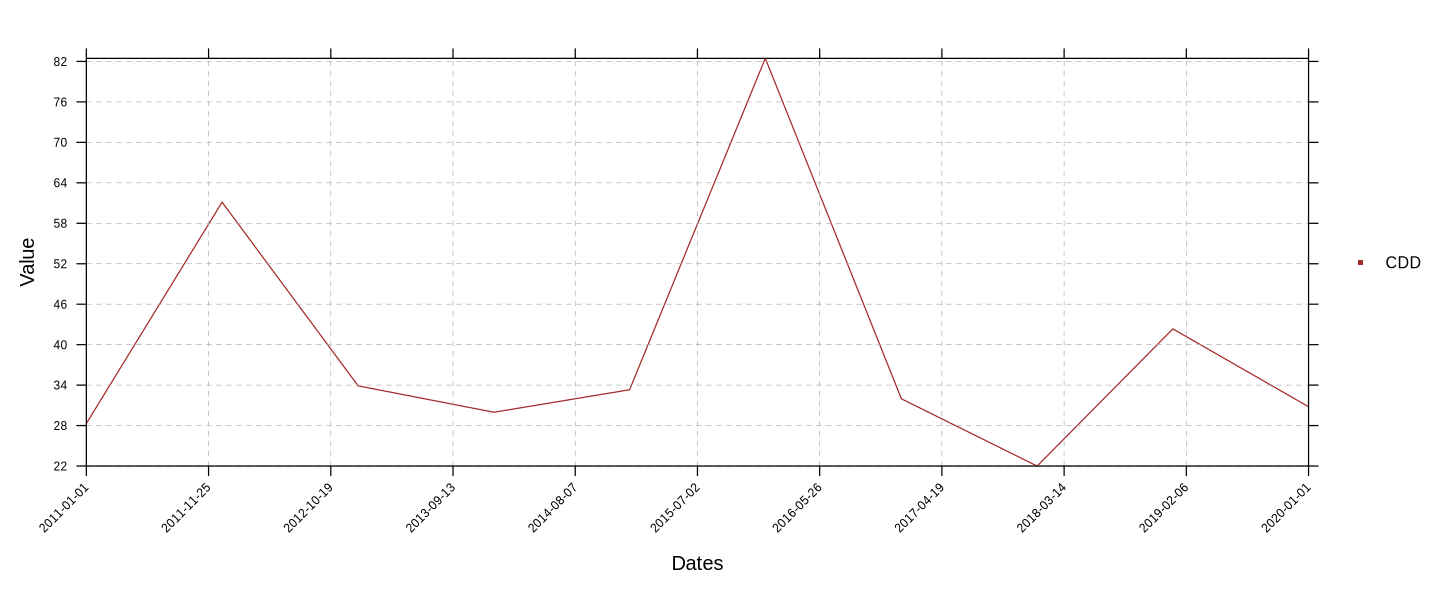

In [14]:
temporalPlot("CDD" = cdd, cols = "brown")


### Visualización de la media de la década

[2026-06-18 15:57:27.350019] - Computing climatology...

[2026-06-18 15:57:27.355029] - Done.



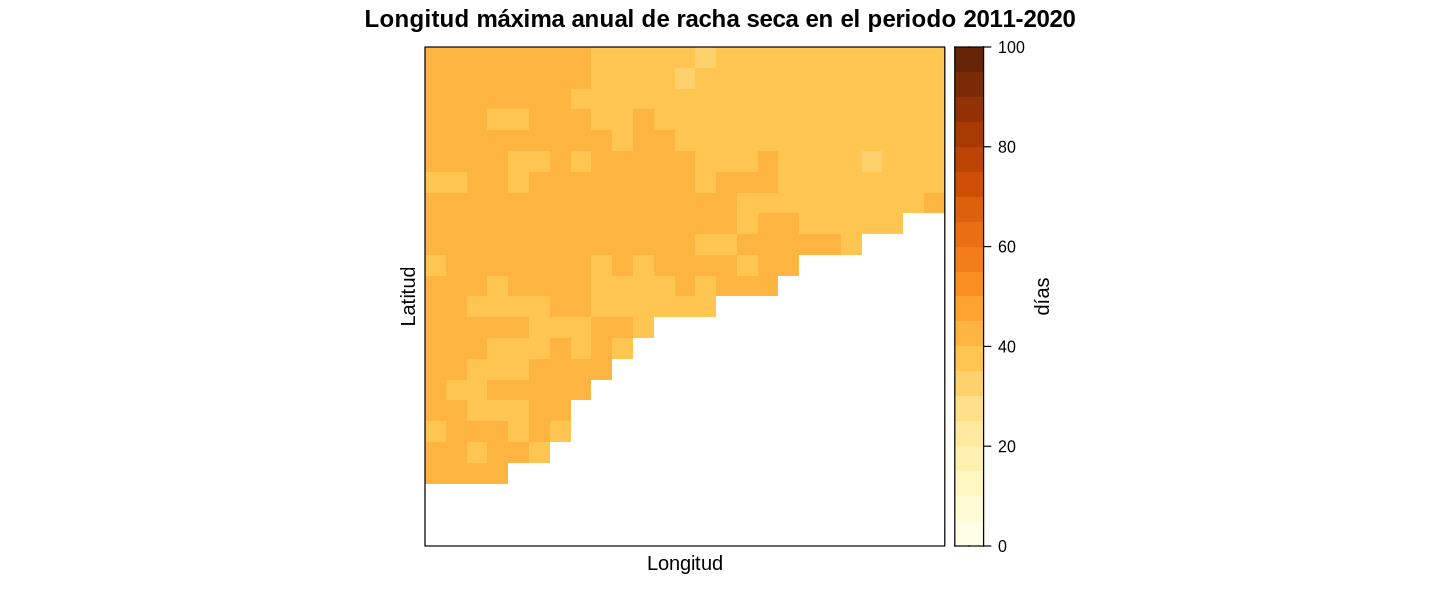

In [15]:
spatialPlot(climatology(cdd), 
            at = seq(0, 100, 5),
            set.max = 100,
            set.min = 0,
            main = "Longitud máxima anual de racha seca en el periodo 2011-2020",
            color.theme = "YlOrBr",
            colorkey = list(space = "right",
                            title = list("días", cex = 1)
                           ),
            xlab = "Longitud",
            ylab = "Latitud")


### Visualización del máximo de la década

In [16]:
cddx <- climatology(cdd, clim.fun = list(FUN = "max"))

[2026-06-18 15:57:27.572915] - Computing climatology...

[2026-06-18 15:57:27.575218] - Done.



[2026-06-18 15:57:27.591735] - Computing climatology...

[2026-06-18 15:57:27.596174] - Done.



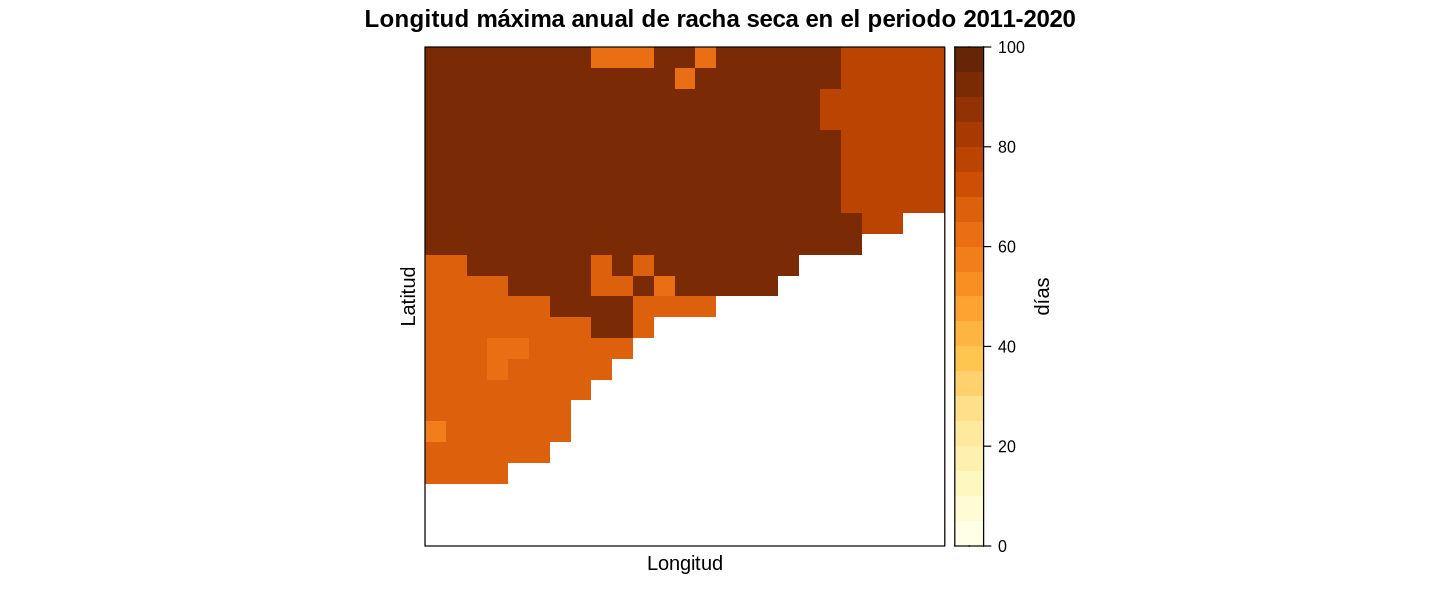

In [17]:
spatialPlot(climatology(cddx), 
            at = seq(0, 100, 5),
            set.max = 100,
            set.min = 0,
            main = "Longitud máxima anual de racha seca en el periodo 2011-2020",
            color.theme = "YlOrBr",
            colorkey = list(space = "right",
                            title = list("días", cex = 1)
                           ),
            xlab = "Longitud",
            ylab = "Latitud")

### Visualización de diferencias entre lustros

A continuación, compararemos los resultados para dos periodos temporales consecutivos (2011–2015 y 2016–2020). Para ello, generaremos los grids correspondientes con `subsetGrid` y, posteriormente, calcularemos la diferencia con `gridArithmetics`.


In [18]:
cdd.2011.2015 <- subsetGrid(cdd, years = 2011:2015)
cdd.2016.2020 <- subsetGrid(cdd, years = 2016:2020)
cdd.anom <- gridArithmetics(climatology(cdd.2016.2020), climatology(cdd.2011.2015), operator = "-")

[2026-06-18 15:57:27.764634] - Computing climatology...

[2026-06-18 15:57:27.777972] - Done.

[2026-06-18 15:57:27.781644] - Computing climatology...

[2026-06-18 15:57:27.786423] - Done.



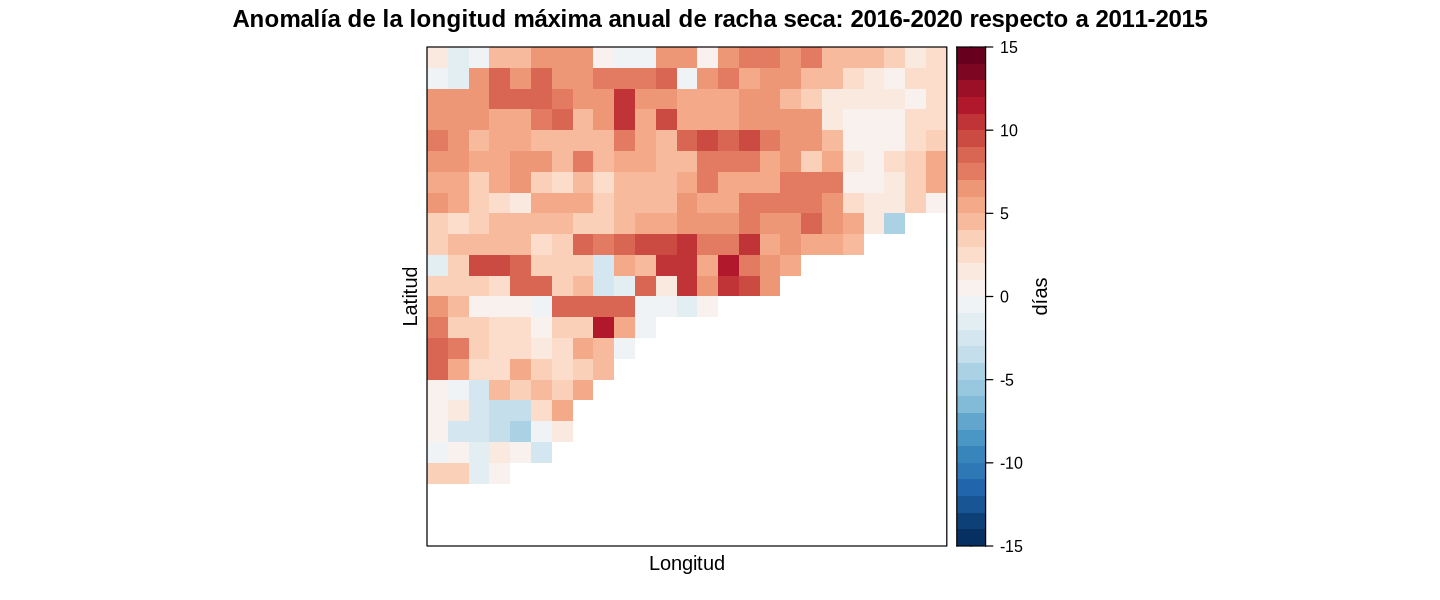

In [19]:
spatialPlot(cdd.anom, 
            at = seq(-15, 15, 1),
            set.max = 15,
            set.min = -15,
            main = "Anomalía de la longitud máxima anual de racha seca: 2016-2020 respecto a 2011-2015", 
            color.theme = "RdBu", 
            rev.colors = TRUE,
            colorkey = list(space = "right",
                            title = list("días", cex = 1)
                           ),
            xlab = "Longitud",
            ylab = "Latitud"
           )


***climate4R*** ofrece más funcionalidades de las que se ilustran en este notebook, como **funcionalidades de operaciones espaciales y temporales** o como **interpolación, subsetting o intersección espacial**. Además, brinda funcionalidades para la **corrección de sesgo y downscaling** o funciones específicas para el **cálculo del FWI**. Consulta [Iturbide et al., 2019](https://www.sciencedirect.com/science/article/pii/S1364815218303049?via%3Dihub) y el repositorio de [github de climate4R](https://github.com/SantanderMetGroup/climate4R) para más información.

La Plataforma Virtual de Cálculo ofrece un **notebook de primeros pasos** y una **colección de notebooks temáticos** (p. ej., intercomparación de conjuntos de datos observacionales o cálculo de índices) que puedes consultar para ampliar el uso de las herramientas y profundizar en los análisis a partir de los datos disponibles en el Almacén.

In [20]:
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 22.04.3 LTS

Matrix products: default
BLAS/LAPACK: /opt/conda/envs/climate4r/lib/libopenblasp-r0.3.28.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8          LC_NUMERIC=C                 
 [3] LC_TIME=en_US.UTF-8           LC_COLLATE=en_US.UTF-8       
 [5] LC_MONETARY=en_US.UTF-8       LC_MESSAGES=en_US.UTF-8      
 [7] LC_PAPER=en_US.UTF-8          LC_NAME=en_US.UTF-8          
 [9] LC_ADDRESS=en_US.UTF-8        LC_TELEPHONE=en_US.UTF-8     
[11] LC_MEASUREMENT=en_US.UTF-8    LC_IDENTIFICATION=en_US.UTF-8

time zone: Etc/UTC
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] climate4R.climdex_0.2.3 climdex.pcic_1.1-11     PCICt_0.5-4.4          
 [4] visualizeR_1.6.4        transformeR_2.2.2       loadeR_1.8.1           
 [7] climate4R.UDG_0.2.6     loadeR.java_1.1.1    